# **Extracción de datos**

In [4]:
import json
import logging
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import date
from pathlib import Path
from typing import Any, Optional
import os

import pandas as pd
import requests

# Desafíos encontrados

## Evaluación de fuentes alternativas

Antes de elegir **RE/MAX** como fuente principal, se realizaron pruebas con distintos portales inmobiliarios. El objetivo era encontrar una fuente que permitiera obtener una cantidad suficiente de publicaciones de CABA y, al mismo tiempo, que pudiera ser consultada de manera estable durante todo el proceso de extracción.

| Fuente | Estrategia utilizada | Resultado | Riesgo para el trabajo |
|---|---|---|---|
| **Zonaprop — ejecución local (ver Anexo II)** | Scraping del HTML utilizando `requests` y `BeautifulSoup`, recorriendo las páginas e incorporando pausas entre consultas. | El proceso funcionaba durante las primeras páginas, pero aproximadamente a partir de la página 10 comenzaban a aparecer bloqueos al detectar las consultas automatizadas. | Alto: no permitía obtener una cantidad suficiente de datos de forma estable. |
| **Argenprop** | Pruebas de scraping desde distintos entornos de ejecución. | Se obtuvieron respuestas bloqueadas o no utilizables debido a mecanismos de protección contra accesos automatizados. | Alto: no se podía garantizar una extracción completa. |
| **CABAPROP (ver Anexo I)** | Consulta de un endpoint JSON realizando búsquedas separadas por barrio. | Permitía recuperar publicaciones, pero al realizar consultas más extensas podían aparecer errores del servidor que interrumpían la extracción. | Alto: no se podía garantizar la cobertura completa de las publicaciones. |
| **RE/MAX** | Consulta de una API paginada y posterior acceso al detalle individual de cada publicación. | Permitió realizar una extracción estable y luego complementar cada propiedad con información adicional. | **Bajo: fuente seleccionada para el TP.** |

Estas pruebas mostraron que no alcanzaba con encontrar un portal que tuviera una gran cantidad de propiedades publicadas. También era necesario que la información pudiera obtenerse de manera suficientemente estable y repetible, ya que una interrupción durante el scraping podía dejar una base incompleta.

<br>

---

## Elección de RE/MAX

Finalmente se eligió **RE/MAX** porque fue la fuente que presentó mayor estabilidad durante las pruebas y permitió construir una base amplia de propiedades ubicadas en CABA.

A partir de la extracción se obtuvieron **16951 publicaciones**, con variables relevantes para el posterior análisis inmobiliario, como precio, moneda, tipo de propiedad, superficie total y cubierta, cantidad de ambientes, dormitorios, baños, barrio y coordenadas geográficas.

Una limitación encontrada fue la variable `Fecha_Publicacion`. Aunque se buscó esta información durante la exploración de los endpoints, no se encontró disponible en las respuestas utilizadas para construir la base. Por este motivo, la columna quedó sin información y esta limitación deberá ser considerada al momento de realizar el análisis.

<br>

---

## Búsqueda de información adicional de cada propiedad

La primera extracción se realizó utilizando el endpoint:

`/findAllWithEntrepreneurships`

Este endpoint permitió obtener el listado general de propiedades y gran parte de las variables principales, como precio, ubicación, superficies y cantidad de ambientes.

Sin embargo, algunas variables útiles para enriquecer la base no aparecían de manera completa o consistente en esta consulta. Entre ellas se encontraban:

- `Descripcion`
- `Amenities`
- `Apto_Credito`
- `Antiguedad`

Por este motivo, se buscó una forma de acceder al detalle individual de cada publicación.

En una primera prueba se utilizó:

`/findById/{id}`

reemplazando `{id}` por el identificador real de una propiedad obtenida previamente. Sin embargo, la consulta devolvía un error **HTTP 500**, por lo que este método no permitía recuperar correctamente la información adicional.

Para entender cómo RE/MAX obtenía los datos cuando un usuario ingresaba normalmente a una publicación, se inspeccionó el HTML de una ficha individual. Allí se encontró un bloque identificado como:

`<script id="ng-state">`

con el JSON completo de la propiedad. El sitio renderiza los datos server-side en vez de pedirlos por fetch/XHR desde el navegador. Ese JSON incluía la URL real que se había usado para generarlo:
`</listings/findBySlug/{slug}>`

Corregimos el scraper para usar esa ruta, con el slug que ya veníamos extrayendo de cada listado.

Ese mismo JSON nos sirvió para confirmar los nombres reales de los campos: description, yearBuilt (año de construcción, no antigüedad directa — hay que restarlo al año actual) y aptCredit.

<br>

---

## Optimización del tiempo de extracción

Una vez encontrado el endpoint de detalle surgió un nuevo problema: era necesario realizar una consulta adicional para cada una de las **16951 propiedades**.

Si estas consultas se realizaban una por una, el proceso completo demoraba demasiado. Por este motivo, se decidió ejecutar varias consultas en paralelo utilizando:

`ThreadPoolExecutor(max_workers=8)`

En lugar de esperar a que termine la consulta de una propiedad para comenzar con la siguiente, esta estrategia permite procesar hasta **8 consultas al mismo tiempo**.

Se eligió trabajar con 8 consultas simultáneas para mejorar el tiempo de extracción sin generar una cantidad excesiva de solicitudes al servidor. De esta manera, se logró reducir considerablemente el tiempo necesario para completar el enriquecimiento de la base.

<br>

---

## Fecha de publicación no existe en ningún endpoint de esta API

Confirmamos que Fecha_Publicacion queda en 0/N en todas las corridas. No es un error del scraper, es un dato que REMAX simplemente no expone públicamente (ni en el listado paginado ni en la ficha de detalle).

<br>

---

## Resultado del proceso de extracción

Finalmente, el proceso quedó dividido en **dos etapas principales**:

1. **Extracción general:** se consulta el listado paginado de RE/MAX para obtener las propiedades y sus características principales.

2. **Enriquecimiento individual:** para cada propiedad obtenida se utiliza su `slug` para consultar el detalle y recuperar variables adicionales, como descripción, amenities, antigüedad y aptitud para crédito.

Esta separación permitió construir una base más completa sin depender únicamente de la información disponible en el listado general.

In [5]:


API_URL = "https://api-ar.redremax.com/remaxweb-ar/api/listings/findAllWithEntrepreneurships"
# CONFIRMADO viendo el <script id="ng-state"> de una ficha real: el
# endpoint de detalle usa el SLUG, no el id numérico ni el internalId.
DETAIL_URL_TEMPLATE = "https://api-ar.redremax.com/remaxweb-ar/api/listings/findBySlug/{slug}"

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/131.0.0.0 Safari/537.36"
    ),
    "Accept": "application/json",
    "Referer": "https://www.remax.com.ar/"
}

# Cantidad máxima de propiedades por página
PAGE_SIZE = 100
# Máximo de páginas de seguridad
MAX_PAGES = 200
# Espera entre páginas (en segundos)
SLEEP_TIME = 1
# Cuántos requests de detalle en simultáneo. RE/MAX no publica un
# límite de rate, así que 8-10 es un número conservador — si empiezan
# a aparecer muchos errores/timeouts en el log, bajarlo.
DETAIL_WORKERS = 8
# Reintentos por request de detalle antes de darse por vencido con esa propiedad
DETAIL_MAX_RETRIES = 2

OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

logging.basicConfig(
    level=logging.INFO,
    format="%(levelname)s: %(message)s"
)
logger = logging.getLogger(__name__)


def safe_get_value(item, key):
    """Extrae de forma segura el valor de claves que pueden ser diccionarios o None."""
    if not isinstance(item, dict):
        return None
    val = item.get(key)
    if isinstance(val, dict):
        return val.get("value") or val.get("name")
    return val


def get_page(page):
    """Consulta la lista masiva de propiedades."""
    params = {
        "page": page,
        "pageSize": PAGE_SIZE,
        "sort": "-createdAt",
        "in": "operationId:1",
        "locations": "in:CF@<b>Capital</b> <b>Federal</b>::::::",
        "landingPath": ""
    }

    try:
        response = requests.get(
            API_URL,
            params=params,
            headers=HEADERS,
            timeout=30
        )
        logger.info(f"Página {page + 1} | Status: {response.status_code}")
        response.raise_for_status()
        return response.json()

    except requests.exceptions.RequestException as e:
        logger.error(f"Error en página {page + 1}: {e}")
    except ValueError as e:
        logger.error(f"Error interpretando JSON en página {page + 1}: {e}")

    return None


def get_listing_detail(slug, property_id=None):
    """
    Consulta el detalle individual por SLUG (confirmado inspeccionando
    el HTML de una ficha real: el endpoint real es findBySlug, no
    findById) para obtener descripción, año de construcción y demás
    campos extra. No traga errores en silencio: los loguea, y devuelve
    un dict vacío solo después de agotar los reintentos.
    """
    if not slug:
        logger.warning(
            f"Propiedad {property_id} sin slug — no se puede pedir el detalle"
        )
        return {}

    url = DETAIL_URL_TEMPLATE.format(slug=slug)

    for intento in range(1, DETAIL_MAX_RETRIES + 1):

        try:
            res = requests.get(url, headers=HEADERS, timeout=10)

            if res.status_code == 200:
                data = res.json()
                if isinstance(data, dict):
                    return data.get("data") or data
                return {}

            if res.status_code == 429:
                logger.warning(
                    f"429 (rate limit) en detalle de {slug}, "
                    f"esperando antes de reintentar (intento {intento})"
                )
                time.sleep(2 * intento)
                continue

            logger.warning(
                f"Status {res.status_code} en detalle de {slug} "
                f"(intento {intento})"
            )

        except requests.exceptions.RequestException as e:
            logger.warning(
                f"Error de conexión en detalle de {slug} "
                f"(intento {intento}): {e}"
            )

    logger.error(
        f"No se pudo obtener el detalle de {slug} "
        f"después de {DETAIL_MAX_RETRIES} intentos — quedará sin "
        f"Descripcion/Antiguedad/Apto_Credito/Amenities"
    )
    return {}


def parse_listing(item, detail):
    if not isinstance(item, dict):
        return None
    if not isinstance(detail, dict):
        detail = {}

    try:
        property_id = item.get("id")

        # CAMPOS ENRIQUECIDOS DESDE EL DETALLE
        descripcion = detail.get("description") or item.get("description") or ""

        # CONFIRMADO: el detalle (findBySlug) no trae ningún campo de
        # fecha de publicación. El listado paginado SÍ se ordena por
        # "-createdAt", así que probablemente ese campo viva en el
        # item del listado, no en el detalle — se busca ahí primero.
        fecha_pub = (
            item.get("createdAt")
            or item.get("publicationDate")
            or detail.get("createdAt")
            or detail.get("publicationDate")
        )

        # CONFIRMADO: la clave real es "yearBuilt" y es el AÑO de
        # construcción (ej. 1970), no la antigüedad en años. Hay que
        # restarlo al año actual para obtener la antigüedad que
        # muestra la página (ej. 2026 - 1970 = 56 años).
        year_built = detail.get("yearBuilt") or item.get("yearBuilt")
        antiguedad = (date.today().year - year_built) if year_built else None

        # CONFIRMADO: clave real "aptCredit" (booleano)
        apto_credito = detail.get("aptCredit")

        # CONFIRMADO: los amenities están en "features" (lista, vacía
        # en propiedades sin amenities cargados)
        features_raw = detail.get("features") or item.get("features")
        amenities = None
        if features_raw:
            valores = []
            for elemento in features_raw:
                if isinstance(elemento, dict):
                    valor = elemento.get("value", elemento.get("name"))
                    if valor:
                        valores.append(str(valor))
                else:
                    valores.append(str(elemento))
            if valores:
                amenities = " | ".join(valores)

        # PRECIO Y MONEDAS CON EXTRACCIÓN SEGURA
        precio = item.get("price")
        moneda = safe_get_value(item, "currency")

        expensas = item.get("expensesPrice")
        moneda_expensas = safe_get_value(item, "expensesCurrency")

        operacion = safe_get_value(item, "operation")
        tipo_propiedad = safe_get_value(item, "type")
        estado = safe_get_value(item, "listingStatus")

        # UBICACIÓN Y BARRIO
        geo_label = item.get("geoLabel")
        barrio = geo_label.split(",")[0].strip() if geo_label else None

        # COORDENADAS
        latitud = None
        longitud = None
        location = item.get("location")
        if isinstance(location, dict):
            coordinates = location.get("coordinates", [])
            if isinstance(coordinates, list) and len(coordinates) >= 2:
                longitud = coordinates[0]
                latitud = coordinates[1]

        # SUPERFICIES
        superficie_total = item.get("dimensionTotalBuilt") or item.get("dimensionLand")
        superficie_cubierta = item.get("dimensionCovered")

        # PRECIOS POR M2
        precio_m2_total = None
        precio_m2_cubierto = None
        if precio is not None:
            if superficie_total and superficie_total > 0:
                precio_m2_total = round(precio / superficie_total, 2)
            if superficie_cubierta and superficie_cubierta > 0:
                precio_m2_cubierto = round(precio / superficie_cubierta, 2)

        # ENLACE
        slug = item.get("slug")
        link = f"https://www.remax.com.ar/listings/{slug}" if slug else f"https://www.remax.com.ar/listings/{property_id}"

        return {
            "ID": property_id,
            "ID_Entidad": item.get("entityId"),
            "Operacion": operacion,
            "Tipo_Propiedad": tipo_propiedad,
            "Titulo": item.get("title"),
            "Descripcion": descripcion,
            "Fecha_Publicacion": fecha_pub,
            "Antiguedad": antiguedad,
            "Apto_Credito": apto_credito,
            "Amenities": amenities,
            "Moneda": moneda,
            "Precio_Valor": precio,
            "Moneda_Expensas": moneda_expensas,
            "Expensas": expensas,
            "Precio_m2_Total": precio_m2_total,
            "Precio_m2_Cubierto": precio_m2_cubierto,
            "Ambientes": item.get("totalRooms"),
            "Dormitorios": item.get("bedrooms"),
            "Baños": item.get("bathrooms"),
            "Superficie_Total_m2": superficie_total,
            "Superficie_Cubierta_m2": superficie_cubierta,
            "Direccion": item.get("displayAddress"),
            "Barrio": barrio,
            "Ubicacion": geo_label,
            "Latitud": latitud,
            "Longitud": longitud,
            "Estado": estado,
            "ID_Interno": item.get("internalId"),
            "Link": link
        }

    except Exception as e:
        logger.error(f"Error procesando propiedad {item.get('id') if isinstance(item, dict) else 'desconocido'}: {e}")
        return None


def obtener_detalles_en_paralelo(listings):
    """
    Pide el detalle de todas las propiedades de una página EN PARALELO
    (hasta DETAIL_WORKERS al mismo tiempo) en vez de una por una. Esto
    es lo que reduce el tiempo total de ~1 hora a unos pocos minutos.
    Devuelve un dict {id: detail}.
    """
    detalles = {}
    with ThreadPoolExecutor(max_workers=DETAIL_WORKERS) as executor:
        futures = {
            executor.submit(get_listing_detail, item.get("slug"), item.get("id")): item.get("id")
            for item in listings
            if isinstance(item, dict) and item.get("id")
        }

        completados = 0
        for future in as_completed(futures):
            property_id = futures[future]
            try:
                detalles[property_id] = future.result()
            except Exception as e:
                logger.error(f"Excepción obteniendo detalle de {property_id}: {e}")
                detalles[property_id] = {}
            completados += 1
            if completados % 20 == 0:
                print(f"      ...detalle {completados}/{len(futures)} propiedades")

    return detalles


def run_scraper():
    all_data = []
    errores_propiedades = 0
    errores_paginas = 0
    paginas_exitosas = 0
    ids_obtenidos = set()

    print("\n" + "=" * 60)
    print("INICIANDO SCRAPER RE/MAX — CABA COMPLETO (paralelo)")
    print("=" * 60)
    print(f"Propiedades por página: {PAGE_SIZE}")
    print(f"Máximo de páginas: {MAX_PAGES}")
    print(f"Workers para detalle: {DETAIL_WORKERS}")
    print("=" * 60)

    for page in range(MAX_PAGES):
        print(f"\nProcesando página {page + 1}...")
        data = get_page(page)

        if data is None:
            errores_paginas += 1
            print(f" No se pudo obtener página {page + 1}")
            time.sleep(3)
            continue

        listings = []
        if isinstance(data, dict):
            raw_data = data.get("data", {})
            if isinstance(raw_data, dict):
                listings = raw_data.get("listings") or raw_data.get("data") or []
            elif isinstance(raw_data, list):
                listings = raw_data

        if not listings:
            print("\n No hay más propiedades.")
            break

        paginas_exitosas += 1
        print(f"   Propiedades recibidas: {len(listings)}")

        # ----------------------------------------------------
        # DETALLE EN PARALELO PARA TODA LA PÁGINA
        # ----------------------------------------------------
        print(f"   Pidiendo detalle de {len(listings)} propiedades...")
        t0 = time.time()
        detalles_por_id = obtener_detalles_en_paralelo(listings)
        print(f"   Detalle completo en {time.time() - t0:.1f}s")

        vacios = sum(1 for d in detalles_por_id.values() if not d)
        if vacios:
            print(f"    {vacios}/{len(listings)} propiedades quedaron sin detalle (ver log de errores arriba)")

        # ----------------------------------------------------
        # PARSEAR PROPIEDADES
        # ----------------------------------------------------
        nuevas = 0
        for item in listings:
            property_id = item.get("id") if isinstance(item, dict) else None
            detail = detalles_por_id.get(property_id, {})
            parsed = parse_listing(item, detail)
            if parsed:
                pid = parsed["ID"]
                if pid not in ids_obtenidos:
                    all_data.append(parsed)
                    ids_obtenidos.add(pid)
                    nuevas += 1
            else:
                errores_propiedades += 1

        print(f"   Propiedades nuevas: {nuevas}")
        print(f"   Total acumulado: {len(all_data)}")

        if len(listings) < PAGE_SIZE:
            print("\n Última página detectada.")
            break

        # Backup de seguridad cada 10 páginas
        if (page + 1) % 10 == 0:
            backup_df = pd.DataFrame(all_data)
            backup_path = os.path.join(OUTPUT_DIR, f"backup_pagina_{page + 1}.csv")
            backup_df.to_csv(backup_path, index=False, encoding="utf-8-sig")
            print(f" Backup guardado: {backup_path}")

        time.sleep(SLEEP_TIME)

    if not all_data:
        print("\n NO SE OBTUVIERON DATOS.")
        return None

    df = pd.DataFrame(all_data)

    # Eliminar duplicados
    cantidad_antes = len(df)
    df = df.drop_duplicates(subset=["ID"])
    duplicados = cantidad_antes - len(df)

    # Convertir variables numéricas
    # esta lista trata todas las numéricas por igual, incluida
    # Fecha_Publicacion (que siempre queda NaN -> float64) y
    # Ambientes/Dormitorios/Baños (que en la práctica nunca traen
    # nulos, por eso terminan como int64 puro y no float/Int64).
    columnas_numericas = [
        "Precio_Valor", "Expensas", "Precio_m2_Total", "Precio_m2_Cubierto",
        "Ambientes", "Dormitorios", "Baños", "Superficie_Total_m2",
        "Superficie_Cubierta_m2", "Antiguedad", "Fecha_Publicacion",
        "Latitud", "Longitud"
    ]
    for columna in columnas_numericas:
        if columna in df.columns:
            df[columna] = pd.to_numeric(df[columna], errors="coerce")

    # Orden final de columnas
    columnas = [
        "ID", "ID_Entidad", "Operacion", "Tipo_Propiedad", "Titulo",
        "Descripcion", "Fecha_Publicacion", "Antiguedad", "Apto_Credito",
        "Amenities",
        "Moneda", "Precio_Valor", "Moneda_Expensas", "Expensas",
        "Precio_m2_Total", "Precio_m2_Cubierto", "Ambientes", "Dormitorios",
        "Baños", "Superficie_Total_m2", "Superficie_Cubierta_m2",
        "Direccion", "Barrio", "Ubicacion", "Latitud", "Longitud",
        "Estado", "ID_Interno", "Link"
    ]
    df = df[[c for c in columnas if c in df.columns]]

    # Exportación
    csv_path = os.path.join(OUTPUT_DIR, "remax_caba_propiedades.csv")
    xlsx_path = os.path.join(OUTPUT_DIR, "remax_caba_propiedades.xlsx")

    df.to_csv(csv_path, index=False, encoding="utf-8-sig")
    df.to_excel(xlsx_path, index=False)

    print("\n" + "=" * 60)
    print("SCRAPING FINALIZADO CON ÉXITO")
    print("=" * 60)
    print(f"Páginas procesadas: {paginas_exitosas}")
    print(f"Registros obtenidos: {len(df)}")
    print(f"Duplicados eliminados: {duplicados}")
    print(f"Errores de propiedades: {errores_propiedades}")
    print(f"Errores de páginas: {errores_paginas}")
    print(f"\nCSV: {csv_path}")
    print(f"Excel: {xlsx_path}")
    print("=" * 60)

    print("\nTIPOS DE PROPIEDAD OBTENIDOS:")
    print(df["Tipo_Propiedad"].value_counts(dropna=False))

    print("\nCOBERTURA DE CAMPOS ENRIQUECIDOS (no nulos / total):")
    for columna in ["Descripcion", "Fecha_Publicacion", "Antiguedad", "Apto_Credito", "Amenities"]:
        if columna in df.columns:
            no_nulos = df[columna].astype(bool).sum() if columna == "Descripcion" else df[columna].notna().sum()
            print(f"  {columna}: {no_nulos}/{len(df)}")

    return df


if __name__ == "__main__":
    df = run_scraper()


INICIANDO SCRAPER RE/MAX — CABA COMPLETO (paralelo)
Propiedades por página: 100
Máximo de páginas: 200
Workers para detalle: 8

Procesando página 1...
   Propiedades recibidas: 100
   Pidiendo detalle de 100 propiedades...
      ...detalle 20/100 propiedades
      ...detalle 40/100 propiedades
      ...detalle 60/100 propiedades
      ...detalle 80/100 propiedades
      ...detalle 100/100 propiedades
   Detalle completo en 4.5s
   Propiedades nuevas: 100
   Total acumulado: 100

Procesando página 2...
   Propiedades recibidas: 100
   Pidiendo detalle de 100 propiedades...
      ...detalle 20/100 propiedades
      ...detalle 40/100 propiedades
      ...detalle 60/100 propiedades
      ...detalle 80/100 propiedades
      ...detalle 100/100 propiedades
   Detalle completo en 4.5s
   Propiedades nuevas: 100
   Total acumulado: 200

Procesando página 3...
   Propiedades recibidas: 100
   Pidiendo detalle de 100 propiedades...
      ...detalle 20/100 propiedades
      ...detalle 40/100 prop

In [9]:
# 23. REVISAR EL RESULTADO
print("\nDIMENSIONES DE LA BASE:")
print(df.shape)

print("\nPRIMERAS FILAS:\n")
display(df.head())


DIMENSIONES DE LA BASE:
(16951, 29)

PRIMERAS FILAS:



,ID,ID_Entidad,Operacion,Tipo_Propiedad,Titulo,Descripcion,Fecha_Publicacion,Antiguedad,Apto_Credito,Amenities,...,Superficie_Total_m2,Superficie_Cubierta_m2,Direccion,Barrio,Ubicacion,Latitud,Longitud,Estado,ID_Interno,Link
0,647516,efe8dd03-f126-4b9f-b8fb-2ff9c0e566c5,sale,departamento_estandar,VENTA DEPARTAMENTO 2 AMBIENTES FLORES BALCÓN,DEPARTAMENTO 2 AMBIENTES CON BALCÓN – MUY LUMI...,NaN,5.0,False,Dormitorio | Baño | Placard | Orientación Nort...,...,50.00,45.00,Tandil 3100,Flores,"Flores, Capital Federal",-34.637677,-58.470202,active,422341020-4,https://www.remax.com.ar/listings/venta-depart...
1,647502,5c6fdb19-512e-4f27-9912-5634512e1925,sale,casa,Local comercial con vivienda - Pompeya- venta,LOCAL CON VIVIENDA TIPO PH EN LOTE PROPIO- TER...,NaN,91.0,False,Electricidad | Agua | Gas | Internet | Desague...,...,341.00,156.00,Avenida Amancio Alcorta 3800,Nueva Pompeya,"Nueva Pompeya, Capital Federal",-34.655694,-58.413883,active,421681005-203,https://www.remax.com.ar/listings/local-comerc...
2,647499,a47e389a-ac7d-44fa-a68b-960abe7d43ee,sale,departamento_estandar,Venta-2 amb a estren vista a la Bombonera- La ...,Excelente departamento 2 ambientes a estrenar ...,NaN,0.0,False,Electricidad | Agua | Gas | Internet | Teléfon...,...,50.00,46.50,Avenida Almirante Brown 700,La Boca,"La Boca, Capital Federal",-34.631619,-58.361735,active,421681005-242,https://www.remax.com.ar/listings/venta-2-amb-...
3,647489,f342a886-efc5-49e7-935b-2cd8a1fdfc4d,sale,ph,VENTA PH 5 AMBIENTES EN PARQUE CHACABUCO,"VENTA PH 5 AMBIENTES EN PARQUE CHACABUCO, CAPI...",NaN,51.0,False,None,...,227.78,170.05,Estrada 400,Parque Chacabuco,"Parque Chacabuco, Capital Federal",-34.631238,-58.432576,active,421241029-246,https://www.remax.com.ar/listings/venta-ph-5-a...
4,647488,edd342d7-3baa-4238-a02f-a379a3abd826,sale,galpon,Venta Galpón + PH + Local en Villa Soldati,VENTA EN BLOCK - Galpón 832 m2 + Oficinas + Lo...,NaN,60.0,False,Electricidad | Agua | Gas | Dormitorio | Vesti...,...,1229.00,1229.00,Corrales 2600,Villa Soldati,"Villa Soldati, Capital Federal",-34.658893,-58.436058,active,420721054-522,https://www.remax.com.ar/listings/venta-galpon...


El esquema maestro se compone de **29 variables**. La clasificación distingue entre identificadores, variables textuales, categóricas, numéricas, temporales, booleanas y estructuras de tipo lista.

##  Analizamos los tipos de datos

In [8]:
print("\nTIPOS DE DATOS: \n")
df.info()


TIPOS DE DATOS: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16951 entries, 0 to 16950
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      16951 non-null  int64  
 1   ID_Entidad              16951 non-null  object 
 2   Operacion               16951 non-null  object 
 3   Tipo_Propiedad          16951 non-null  object 
 4   Titulo                  16951 non-null  object 
 5   Descripcion             16951 non-null  object 
 6   Fecha_Publicacion       0 non-null      float64
 7   Antiguedad              16372 non-null  float64
 8   Apto_Credito            16838 non-null  object 
 9   Amenities               12986 non-null  object 
 10  Moneda                  16951 non-null  object 
 11  Precio_Valor            16951 non-null  float64
 12  Moneda_Expensas         16949 non-null  object 
 13  Expensas                15737 non-null  float64
 14  Precio_m2_Total    

##variables

Se presenta la estructura de la base obtenida, indicando el tipo de dato asignado por `pandas`, la clasificación de cada variable y un ejemplo de los valores observados.

| Variable | Dtype (pandas) | Clasificación técnica | Ejemplo de valor |
|---|---|---|---|
| `ID` | `int64` | Identificador único | `639768` |
| `ID_Entidad` | `object` | Identificador (UUID) | `"dc889455-70ed-4d9f-b046-7bb7b5d97a4e"` |
| `Operacion` | `object` | Categórico nominal | `"sale"` |
| `Tipo_Propiedad` | `object` | Categórico nominal | `"departamento_estandar"` |
| `Titulo` | `object` | Textual (texto libre corto) | `"Venta Depto 2 Ambientes en pozo en el Barrio Nuñez"` |
| `Descripcion` | `object` | Textual (texto libre extenso) | `"Departamento 2 Ambientes en pozo en el barrio de Nuñez..."` |
| `Fecha_Publicacion` | `float64` | Temporal (siempre nulo en esta fuente — limitación documentada) | `NaN` |
| `Antiguedad` | `float64` | Numérico continuo (derivado: año actual − año de construcción) | `50.0` |
| `Apto_Credito` | `object` | Dicotómico / booleano | `False` |
| `Amenities` | `object` | Estructurado (lista serializada como texto, separador `\|`) | `"Electricidad \| Agua \| Gas \| Pileta \| Gimnasio"` |
| `Moneda` | `object` | Categórico nominal | `"USD"` |
| `Precio_Valor` | `float64` | Numérico continuo | `178500.0` |
| `Moneda_Expensas` | `object` | Categórico nominal | `"ARS"` |
| `Expensas` | `float64` | Numérico continuo | `200000.0` |
| `Precio_m2_Total` | `float64` | Numérico continuo (derivado) | `3077.59` |
| `Precio_m2_Cubierto` | `float64` | Numérico continuo (derivado) | `3432.69` |
| `Ambientes` | `int64` | Numérico discreto | `2` |
| `Dormitorios` | `int64` | Numérico discreto | `1` |
| `Baños` | `int64` | Numérico discreto | `1` |
| `Superficie_Total_m2` | `float64` | Numérico continuo | `58.0` |
| `Superficie_Cubierta_m2` | `float64` | Numérico continuo | `52.0` |
| `Direccion` | `object` | Textual (dirección postal) | `"Avenida Cabildo 4900"` |
| `Barrio` | `object` | Categórico nominal | `"Nuñez"` |
| `Ubicacion` | `object` | Textual / categórico compuesto | `"Nuñez, Capital Federal"` |
| `Latitud` | `float64` | Numérico continuo (geoespacial) | `-34.539389` |
| `Longitud` | `float64` | Numérico continuo (geoespacial) | `-58.475075` |
| `Estado` | `object` | Categórico nominal (estado de la publicación) | `"active"` |
| `ID_Interno` | `object` | Identificador | `"420571172-19"` |
| `Link` | `object` | Textual (URL) | `"https://www.remax.com.ar/listings/venta-depto-2-ambientes..."` |

#  Anexo

*(En este apartado agregamos otros lugares que tuvimos en cuenta para scrapear.)*


### I. Scrapeo de Cabaprop
estos registros fueron descartados para su uso debido a los pocos registros que se lograron tomar (2664 filas)

In [10]:
import requests
import pandas as pd
import time
import logging
import os

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
logger = logging.getLogger(__name__)

API_URL = "https://cabaprop.com.ar/api/v1/properties/find-properties"

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/121.0.0.0 Safari/537.36"
    ),
    "Accept": "application/json",
    "Content-Type": "application/json",
    "Referer": "https://cabaprop.com.ar/propiedades/comprar-casa-departamento-ph",
    "Origin": "https://cabaprop.com.ar",
}

LIMIT = 12  # confirmado: el que usa el sitio real
SLEEP_TIME = 0.5

# Lista completa de barrios de CABA según el sitio (endpoint
# /api/v1/utils/barrios-flat) — recorremos uno por uno para que cada
# consulta quede muy por debajo del límite de profundidad de
# paginación que corta la búsqueda general de CABA entera (~2000).
BARRIOS = {
    1: "Abasto", 2: "Agronomía", 3: "Almagro", 4: "Almagro Norte", 5: "Almagro Sur",
    6: "Balvanera", 7: "Balvanera Congreso", 8: "Balvanera Once", 9: "Barracas",
    10: "Barrio Norte", 11: "Barrio Norte La Isla", 12: "Barrio Norte Parque Las Heras",
    13: "Barrio Norte Recoleta", 14: "Belgrano", 15: "Belgrano Barrancas", 16: "Belgrano C",
    17: "Belgrano La Imprenta", 18: "Belgrano R", 19: "Boedo", 20: "Caballito",
    21: "Caballito Barrio Inglés", 22: "Caballito Cid Campeador", 23: "Caballito Norte",
    24: "Caballito Parque Rivadavia", 25: "Caballito Primera Junta", 26: "Caballito Sur",
    27: "Chacarita", 28: "Coghlan", 29: "Colegiales", 30: "Constitución", 31: "Flores",
    32: "Flores Norte", 33: "Flores Sur", 34: "Floresta", 35: "Floresta Norte",
    36: "Floresta Sur", 37: "La Boca", 38: "La Paternal", 39: "Liniers", 40: "Mataderos",
    41: "Microcentro / Centro", 42: "Monserrat", 43: "Monte Castro", 44: "Nuñez",
    45: "Nuñez Lomas", 46: "Nuñez River", 47: "Palermo", 48: "Palermo Botánico",
    49: "Palermo Boulevard", 50: "Palermo Chico", 51: "Palermo Hollywood",
    52: "Palermo Las Cañitas", 53: "Palermo Pacífico", 54: "Palermo Plaza Italia",
    55: "Palermo Soho", 56: "Palermo Viejo", 57: "Parque Avellaneda",
    58: "Parque Centenario", 59: "Parque Chacabuco", 60: "Parque Chas",
    61: "Parque Patricios", 62: "Pompeya", 63: "Primera Junta", 64: "Puerto Madero",
    65: "Retiro", 66: "Retiro Catalinas", 67: "Retiro Plaza San Martín", 68: "Saavedra",
    69: "San Cristóbal", 70: "San Nicolás", 71: "San Nicolás Tribunales", 72: "San Telmo",
    73: "Vélez Sarsfield", 74: "Versalles", 75: "Villa Crespo", 76: "Villa del Parque",
    77: "Villa Devoto", 78: "Villa General Mitre", 79: "Villa Lugano", 80: "Villa Luro",
    81: "Villa Ortúzar", 82: "Villa Pueyrredón", 83: "Villa Real", 84: "Villa Riachuelo",
    85: "Villa Santa Rita", 86: "Villa Soldati", 87: "Villa Urquiza", 88: "Recoleta",
}

OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

SESSION = requests.Session()
SESSION.headers.update(HEADERS)


def get_page(offset, barrio_id):

    params = {
        "offset": offset,
        "limit": LIMIT,
        "orderBy": "created_at",
        "sort": "desc",
    }

    body = {
        "operationType": 1,
        "propertyTypes": [2, 1, 3],
        "barrios": [barrio_id],
        "ambiences": [],
        "antiquity": "",
        "bathrooms": 0,
        "bedrooms": [],
        "characteristics": [],
        "extras": [],
        "garages": 0,
        "price": {"currency": "ARS", "min": 0, "max": 0, "tag": "pesos"},
        "surface": {"tag": "superficieTotal", "type": "totalSurface", "min": "", "max": ""},
    }

    try:
        r = SESSION.post(API_URL, params=params, json=body, timeout=20)

        if r.status_code == 500:
            # Puede seguir siendo el límite de profundidad, incluso
            # acotado por barrio, en barrios muy grandes
            return None

        r.raise_for_status()
        return r.json()

    except requests.exceptions.RequestException as e:
        logger.error(f"Error en barrio {barrio_id}, offset {offset}: {e}")

    return None


def parse_property(item, barrio_nombre_filtro):

    try:
        location = item.get("location") or {}
        surface = item.get("surface") or {}
        antiquity = item.get("antiquity") or {}
        price = item.get("price") or {}
        characteristics = item.get("characteristics") or {}
        garages = characteristics.get("garages") or {}
        publication = item.get("publication") or {}
        seller_address = publication.get("seller_address") or {}
        search_location = seller_address.get("search_location") or {}
        neighborhood = search_location.get("neighborhood") or {}
        extras = item.get("extras") or {}
        adicionales = extras.get("adicionales") or {}

        amenities_activos = [k for k, v in adicionales.items() if v is True] if adicionales else []

        return {
            "Fuente": "CABAPROP",
            "ID": item.get("_id"),
            "ML_ID": item.get("ml_id"),
            "Titulo": item.get("title"),
            "Descripcion": item.get("description"),
            "Estado_Publicacion": item.get("status"),
            "Operacion_Tipo": item.get("operation_type"),
            "Propiedad_Tipo": item.get("property_type"),
            "Direccion": location.get("street"),
            "Altura": location.get("number"),
            "Barrio": neighborhood.get("name") or barrio_nombre_filtro,
            "Localidad": location.get("area_level_2"),
            "Latitud": location.get("lat"),
            "Longitud": location.get("lng"),
            "Superficie_Total_m2": surface.get("totalSurface"),
            "Superficie_Cubierta_m2": surface.get("coveredSurface"),
            "Antiguedad": antiquity.get("years"),
            "Moneda": publication.get("currency_id"),
            "Precio_Valor": price.get("total"),
            "Expensas": price.get("expenses"),
            "Ambientes": characteristics.get("ambience"),
            "Dormitorios": characteristics.get("bedrooms"),
            "Baños": characteristics.get("bathrooms"),
            "Cocheras": garages.get("quantity"),
            "Apto_Credito": characteristics.get("aptCredito"),
            "Apto_Profesional": characteristics.get("aptProfesional"),
            "Apto_Mascota": characteristics.get("aptMascota"),
            "Amenities": " | ".join(amenities_activos) if amenities_activos else None,
            "Fecha_Publicacion": publication.get("start_time"),
            "Fecha_Vencimiento": publication.get("expiration_time"),
            "Link": publication.get("permalink"),
        }

    except Exception as e:
        logger.error(f"Error procesando propiedad {item.get('_id')}: {e}")
        return None


def recorrer_barrio(barrio_id, barrio_nombre, all_data, seen_ids):

    nuevas_barrio = 0
    offset = 0

    while True:

        data = get_page(offset, barrio_id)

        if data is None:
            logger.warning(f"  {barrio_nombre}: se cortó en offset {offset} (límite del backend)")
            break

        results = data.get("result", [])

        if not results:
            break

        for item in results:
            parsed = parse_property(item, barrio_nombre)
            if parsed and parsed["ID"] and parsed["ID"] not in seen_ids:
                seen_ids.add(parsed["ID"])
                all_data.append(parsed)
                nuevas_barrio += 1

        offset += LIMIT
        time.sleep(SLEEP_TIME)

    return nuevas_barrio


def run_scraper():

    all_data = []
    seen_ids = set()

    print("\n" + "=" * 60)
    print(f"INICIANDO SCRAPER CABAPROP — CABA, por barrio ({len(BARRIOS)} barrios)")
    print("=" * 60)

    for i, (barrio_id, barrio_nombre) in enumerate(BARRIOS.items(), start=1):

        print(f"\n[{i}/{len(BARRIOS)}] {barrio_nombre} (id={barrio_id})")

        nuevas = recorrer_barrio(barrio_id, barrio_nombre, all_data, seen_ids)

        print(f"   Propiedades nuevas: {nuevas} | Total acumulado: {len(all_data)}")

        # Guardado incremental — si algo corta a mitad de camino, no se pierde nada
        pd.DataFrame(all_data).to_csv(
            os.path.join(OUTPUT_DIR, "cabaprop_caba_venta.csv"),
            index=False, encoding="utf-8-sig"
        )

    if not all_data:
        print("\n No se obtuvieron datos.")
        return None

    df = pd.DataFrame(all_data)

    csv_path = os.path.join(OUTPUT_DIR, "cabaprop_caba_venta.csv")
    xlsx_path = os.path.join(OUTPUT_DIR, "cabaprop_caba_venta.xlsx")

    df.to_csv(csv_path, index=False, encoding="utf-8-sig")
    df.to_excel(xlsx_path, index=False)

    print("\n" + "=" * 60)
    print("SCRAPING FINALIZADO")
    print("=" * 60)
    print(f"Total de avisos: {len(df)}")
    print(f"\nCSV: {csv_path}")
    print(f"Excel: {xlsx_path}")

    print("\nCOBERTURA DE CAMPOS CLAVE (no nulos / total):")
    for columna in ["Descripcion", "Antiguedad", "Fecha_Publicacion", "Apto_Credito", "Amenities", "Barrio"]:
        if columna in df.columns:
            no_nulos = df[columna].notna().sum()
            print(f"  {columna}: {no_nulos}/{len(df)}")

    return df


if __name__ == "__main__":
    df = run_scraper()


INICIANDO SCRAPER CABAPROP — CABA, por barrio (88 barrios)

[1/88] Abasto (id=1)
   Propiedades nuevas: 12 | Total acumulado: 12

[2/88] Agronomía (id=2)
   Propiedades nuevas: 12 | Total acumulado: 24

[3/88] Almagro (id=3)
   Propiedades nuevas: 84 | Total acumulado: 108

[4/88] Almagro Norte (id=4)
   Propiedades nuevas: 40 | Total acumulado: 148

[5/88] Almagro Sur (id=5)
   Propiedades nuevas: 10 | Total acumulado: 158

[6/88] Balvanera (id=6)
   Propiedades nuevas: 96 | Total acumulado: 254

[7/88] Balvanera Congreso (id=7)
   Propiedades nuevas: 23 | Total acumulado: 277

[8/88] Balvanera Once (id=8)
   Propiedades nuevas: 19 | Total acumulado: 296

[9/88] Barracas (id=9)
   Propiedades nuevas: 60 | Total acumulado: 356

[10/88] Barrio Norte (id=10)
   Propiedades nuevas: 84 | Total acumulado: 440

[11/88] Barrio Norte La Isla (id=11)
   Propiedades nuevas: 2 | Total acumulado: 442

[12/88] Barrio Norte Parque Las Heras (id=12)
   Propiedades nuevas: 2 | Total acumulado: 444

[

####  II. Zonaprop - local

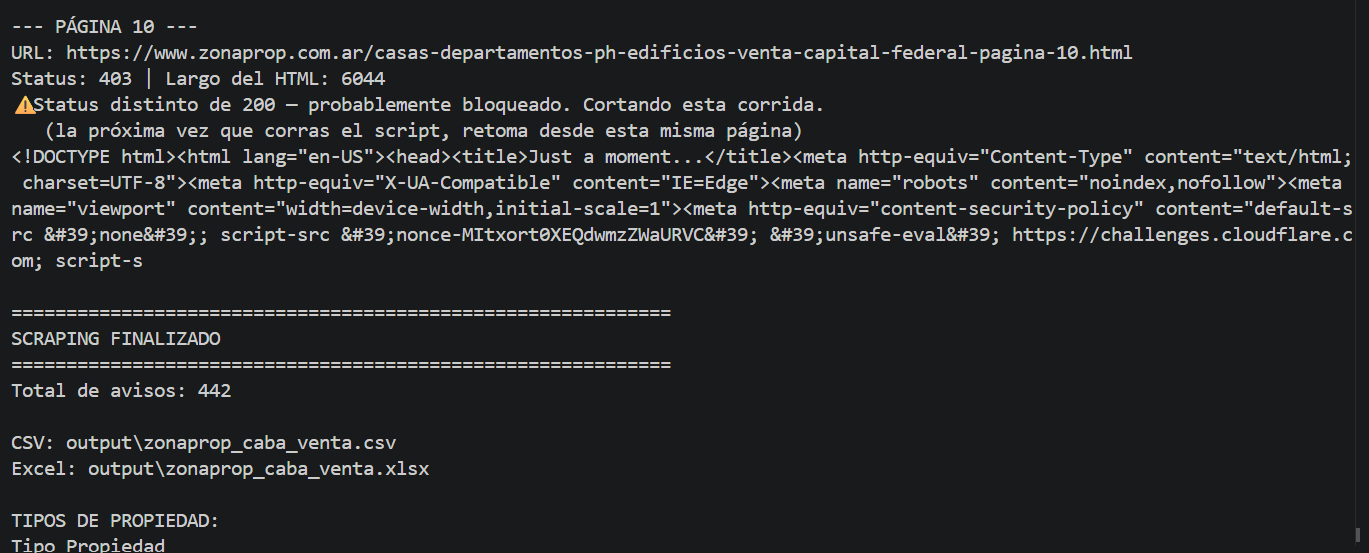

####  Zonaprop desde colab bloqueaba desde la página 1.

In [12]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re
import json
import time
import os
import logging

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
logger = logging.getLogger(__name__)

BASE_URL = "https://www.zonaprop.com.ar/casas-departamentos-ph-edificios-venta-capital-federal.html"

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/121.0.0.0 Safari/537.36"
    ),
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,*/*;q=0.8",
    "Accept-Language": "es-AR,es;q=0.9",
}

MAX_PAGES_POR_CORRIDA = 8  # límite prudente por sesión, por debajo del punto donde aparece el bloqueo
SLEEP_TIME = 2.0  # más pausado, para parecer menos "bot"

OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

CSV_PATH = os.path.join(OUTPUT_DIR, "zonaprop_caba_venta.csv")
PROGRESS_PATH = os.path.join(OUTPUT_DIR, "zonaprop_progress.txt")

# Tipos de propiedad válidos conocidos — cualquier otra cosa que salga
# del parseo del alt de la imagen (códigos internos, nombres de foto
# sueltos, etc.) se descarta en vez de dejarla "sucia" en el dataset.
TIPOS_VALIDOS = {
    "departamento", "casa", "ph", "edificio", "oficina", "local",
    "terreno", "lote", "cochera", "galpón", "galpon", "depósito",
    "deposito", "quinta", "campo", "hotel", "fondo de comercio"
}

SESSION = requests.Session()
SESSION.headers.update(HEADERS)


def leer_ultima_pagina():
    """Lee hasta qué página se llegó en la corrida anterior (0 si es la primera vez)."""
    if os.path.exists(PROGRESS_PATH):
        with open(PROGRESS_PATH, "r") as f:
            contenido = f.read().strip()
            if contenido.isdigit():
                return int(contenido)
    return 0


def guardar_ultima_pagina(pagina):
    with open(PROGRESS_PATH, "w") as f:
        f.write(str(pagina))


def get_page_url(page):
    if page == 1:
        return BASE_URL
    return BASE_URL.replace(".html", f"-pagina-{page}.html")


def extraer_id_de_url(url):
    """Saca el ID numérico del final de una URL de Zonaprop (ej: ...-56135149.html -> 56135149)."""
    if not url:
        return None
    m = re.search(r'-(\d+)\.html', url)
    return m.group(1) if m else None


def parsear_jsonld_listado(html_text):
    """
    El listado trae, entre sus varios bloques <script type="application/ld+json">,
    uno con mainEntity que contiene la DESCRIPCIÓN COMPLETA y la fecha real
    de publicación (datePosted) de cada propiedad de la página — gratis,
    sin pedir la ficha individual. Devuelve un dict {id: {...}}.
    """

    resultado = {}

    bloques = re.findall(
        r'<script[^>]*type="application/ld\+json"[^>]*>(.*?)</script>',
        html_text, re.DOTALL
    )

    for bloque in bloques:
        try:
            data = json.loads(bloque)
        except json.JSONDecodeError:
            continue

        if not isinstance(data, dict) or "mainEntity" not in data:
            continue

        for entrada in data["mainEntity"]:
            prop_id = extraer_id_de_url(entrada.get("url"))
            if prop_id:
                resultado[prop_id] = {
                    "Descripcion_Completa": entrada.get("description"),
                    "Fecha_Publicacion": entrada.get("datePosted"),
                }

        break  # ya encontramos el bloque bueno, no hace falta seguir

    return resultado


def parse_card(card):

    try:
        property_id = card.get("data-id")

        to_posting = card.get("data-to-posting") or ""
        to_posting_limpio = to_posting.split("?")[0]
        link = f"https://www.zonaprop.com.ar{to_posting_limpio}" if to_posting_limpio else None

        precio_tag = card.find(attrs={"data-qa": "POSTING_CARD_PRICE"})
        precio_texto = precio_tag.get_text(strip=True) if precio_tag else None

        moneda = None
        precio = None
        if precio_texto:
            m = re.match(r"([A-Za-z$]+)\s*([\d.,]+)", precio_texto)
            if m:
                moneda = m.group(1)
                precio = float(m.group(2).replace(".", "").replace(",", "."))

        expensas_tag = card.find(attrs={"data-qa": "expensas"})
        expensas_texto = expensas_tag.get_text(strip=True) if expensas_tag else None
        expensas = None
        if expensas_texto:
            m = re.search(r"([\d.,]+)", expensas_texto)
            if m:
                expensas = float(m.group(1).replace(".", "").replace(",", "."))

        features_tag = card.find(attrs={"data-qa": "POSTING_CARD_FEATURES"})
        superficie_total = ambientes = dormitorios = banos = None

        if features_tag:
            for span in features_tag.find_all("span"):
                texto = span.get_text(strip=True)
                if "m²" in texto:
                    m = re.search(r"([\d.,]+)\s*m²", texto)
                    if m:
                        superficie_total = float(m.group(1).replace(".", "").replace(",", "."))
                elif "amb" in texto:
                    m = re.search(r"(\d+)", texto)
                    if m:
                        ambientes = int(m.group(1))
                elif "dorm" in texto:
                    m = re.search(r"(\d+)", texto)
                    if m:
                        dormitorios = int(m.group(1))
                elif "baño" in texto:
                    m = re.search(r"(\d+)", texto)
                    if m:
                        banos = int(m.group(1))

        location_block = card.find("div", class_=lambda c: c and "location-block" in c)
        direccion = None
        if location_block:
            h4s = location_block.find_all("h4")
            if h4s:
                direccion = h4s[0].get_text(strip=True)

        ubicacion_tag = card.find(attrs={"data-qa": "POSTING_CARD_LOCATION"})
        ubicacion_texto = ubicacion_tag.get_text(strip=True) if ubicacion_tag else None
        barrio = ubicacion_texto.split(",")[0].strip() if ubicacion_texto else None

        descripcion_tag = card.find(attrs={"data-qa": "POSTING_CARD_DESCRIPTION"})
        descripcion_resumida = descripcion_tag.get_text(strip=True) if descripcion_tag else None

        tipo_propiedad = titulo = None
        gallery = card.find("div", class_=lambda c: c and "gallery-container" in c)
        img_tag = gallery.find("img") if gallery else None

        if img_tag and img_tag.get("alt") and "·" in img_tag["alt"]:
            partes = [p.strip() for p in img_tag["alt"].split("·")]
            if partes and partes[0].lower() in TIPOS_VALIDOS:
                tipo_propiedad = partes[0]
            if len(partes) >= 4:
                titulo = partes[-1]

        precio_m2 = round(precio / superficie_total, 2) if (precio and superficie_total and superficie_total > 0) else None

        return {
            "Fuente": "Zonaprop",
            "ID": property_id,
            "Titulo": titulo,
            "Tipo_Propiedad": tipo_propiedad,

            "Moneda": moneda,
            "Precio_Valor": precio,
            "Expensas": expensas,

            "Superficie_Total_m2": superficie_total,
            "Precio_m2_Total": precio_m2,

            "Ambientes": ambientes,
            "Dormitorios": dormitorios,
            "Baños": banos,

            "Direccion": direccion,
            "Barrio": barrio,
            "Ubicacion": ubicacion_texto,

            "Descripcion_Resumida": descripcion_resumida,

            "Link": link,
        }

    except Exception as e:
        logger.error(f"Error procesando una tarjeta: {e}")
        return None


def run_scraper(paginas_por_corrida=MAX_PAGES_POR_CORRIDA):

    -------
    # CARGAR LO YA CONSEGUIDO EN CORRIDAS ANTERIORES (si existe)
    -------

    all_data = []
    seen_ids = set()

    if os.path.exists(CSV_PATH):
        df_previo = pd.read_csv(CSV_PATH, dtype={"ID": str})
        all_data = df_previo.to_dict("records")
        seen_ids = set(df_previo["ID"].dropna().astype(str))
        print(f" Cargados {len(all_data)} avisos de corridas anteriores.")

    pagina_inicial = leer_ultima_pagina() + 1
    pagina_final = pagina_inicial + paginas_por_corrida - 1

    print(f"[DEBUG] paginas_por_corrida recibido: {paginas_por_corrida}")
    print(f"[DEBUG] pagina_inicial: {pagina_inicial} | pagina_final: {pagina_final}")

    print("\n" + "=" * 60)
    print("INICIANDO SCRAPER ZONAPROP — CABA")
    print(f"Retomando desde la página {pagina_inicial} hasta la {pagina_final}")
    print("=" * 60)

    for page in range(pagina_inicial, pagina_final + 1):

        url = get_page_url(page)

        print(f"\n--- PÁGINA {page} ---")
        print(f"URL: {url}")

        try:
            r = SESSION.get(url, timeout=20)
        except requests.exceptions.RequestException as e:
            logger.error(f"Error en página {page}: {e}")
            time.sleep(3)
            continue

        print(f"Status: {r.status_code} | Largo del HTML: {len(r.text)}")

        if r.status_code != 200:
            print(" Status distinto de 200 — probablemente bloqueado. Cortando esta corrida.")
            print("   (la próxima vez que corras el script, retoma desde esta misma página)")
            print(r.text[:500])
            break

        soup = BeautifulSoup(r.text, "html.parser")
        cards = soup.find_all("div", attrs={"data-posting-type": "PROPERTY"})

        if not cards:
            print("\n 0 tarjetas encontradas — fin real del listado.")
            guardar_ultima_pagina(page)  # no volver a intentar esta página
            break

        print(f"Tarjetas encontradas: {len(cards)}")

        jsonld_por_id = parsear_jsonld_listado(r.text)
        print(f"Propiedades con descripción completa (JSON-LD): {len(jsonld_por_id)}")

        filas_pagina = []

        for card in cards:

            parsed = parse_card(card)

            if not parsed or not parsed["ID"] or parsed["ID"] in seen_ids:
                continue

            seen_ids.add(parsed["ID"])

            extra = jsonld_por_id.get(parsed["ID"], {})
            parsed["Descripcion_Completa"] = extra.get("Descripcion_Completa")
            parsed["Fecha_Publicacion"] = extra.get("Fecha_Publicacion")

            filas_pagina.append(parsed)

        all_data.extend(filas_pagina)

        print(f"Nuevas: {len(filas_pagina)} | Total acumulado: {len(all_data)}")

        # Guardamos el progreso YA, página por página — así si el
        # bloqueo aparece en la página siguiente, no se pierde nada
        # de lo ya conseguido en esta corrida.
        guardar_ultima_pagina(page)

        df_parcial = pd.DataFrame(all_data)
        df_parcial.to_csv(CSV_PATH, index=False, encoding="utf-8-sig")

        time.sleep(SLEEP_TIME)

    if not all_data:
        print("\n No se obtuvieron datos.")
        return None

    df = pd.DataFrame(all_data)

    csv_path = CSV_PATH
    xlsx_path = os.path.join(OUTPUT_DIR, "zonaprop_caba_venta.xlsx")

    df.to_csv(csv_path, index=False, encoding="utf-8-sig")
    df.to_excel(xlsx_path, index=False)

    print("\n" + "=" * 60)
    print("SCRAPING FINALIZADO")
    print("=" * 60)
    print(f"Total de avisos: {len(df)}")
    print(f"\nCSV: {csv_path}")
    print(f"Excel: {xlsx_path}")

    print("\nTIPOS DE PROPIEDAD:")
    print(df["Tipo_Propiedad"].value_counts(dropna=False))

    print("\nCOBERTURA DE CAMPOS ENRIQUECIDOS:")
    for columna in ["Descripcion_Completa", "Fecha_Publicacion"]:
        if columna in df.columns:
            no_nulos = df[columna].notna().sum()
            print(f"  {columna}: {no_nulos}/{len(df)}")

    return df


if __name__ == "__main__":
    # Cada corrida trae ~8 páginas nuevas (retomando donde quedó la
    # anterior) y guarda el progreso solo. Correr este script varias
    # veces a lo largo del día hasta juntar los 10 mil+.
    df = run_scraper(paginas_por_corrida=12)

[DEBUG] paginas_por_corrida recibido: 12
[DEBUG] pagina_inicial: 1 | pagina_final: 12

INICIANDO SCRAPER ZONAPROP — CABA
Retomando desde la página 1 hasta la 12

--- PÁGINA 1 ---
URL: https://www.zonaprop.com.ar/casas-departamentos-ph-edificios-venta-capital-federal.html
Status: 403 | Largo del HTML: 5970
 Status distinto de 200 — probablemente bloqueado. Cortando esta corrida.
   (la próxima vez que corras el script, retoma desde esta misma página)
<!DOCTYPE html><html lang="en-US"><head><title>Just a moment...</title><meta http-equiv="Content-Type" content="text/html; charset=UTF-8"><meta http-equiv="X-UA-Compatible" content="IE=Edge"><meta name="robots" content="noindex,nofollow"><meta name="viewport" content="width=device-width,initial-scale=1"><meta http-equiv="content-security-policy" content="default-src &#39;none&#39;; script-src &#39;nonce-jSar0mIERy4lAw9DuQCWcS&#39; &#39;unsafe-eval&#39; https://challenges.cloudflare.com; script-s

 No se obtuvieron datos.


#### III. Argenprop
La extracción mediante requests HTTP simples no resultó viable de forma estable, ya que Argenprop respondió con HTTP 405 y una página de Human Verification asociada a AWS WAF.

In [17]:
import requests
from bs4 import BeautifulSoup

URL = "https://www.argenprop.com/departamentos/venta/capital-federal"

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/121.0.0.0 Safari/537.36"
    ),
    "Accept": (
        "text/html,application/xhtml+xml,"
        "application/xml;q=0.9,image/webp,*/*;q=0.8"
    ),
    "Accept-Language": "es-AR,es;q=0.9",
}

response = requests.get(
    URL,
    headers=HEADERS,
    timeout=20
)

print("STATUS:", response.status_code)
print("Tamaño HTML:", len(response.text))

print("\nPrimeros 500 caracteres:")
print(response.text[:500])

STATUS: 405
Tamaño HTML: 2694

Primeros 500 caracteres:
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="utf-8">
    <meta name="viewport" content="width=device-width, initial-scale=1">
    <title>Human Verification</title>
    <style>
        body {
            font-family: "Arial";
        }
    </style>
    <script type="text/javascript">
    window.awsWafCookieDomainList = ['sosiva451.com','argenprop.com','buscainmueble.com','inmuebles.clarin.com','argenprop.com.ar','inmuebles.clarin.com.ar','buscainmueble.com.ar','creditos451.com','gar
